Looking at the distribution of folds in different kingdoms of life: 

- Total number of folds (xgroups) in ECOD v279 is **2458**.
- Of these, **2230** folds have a phyletic distribution score > 0 in bacteria, archaea or eukaryote genomes from GTDB and EukProt3
- Eukaryotes have **1508** of folds with distribution score > 0 with both DS_average & DS_50%.
- With DS_average, bacteria have **1578**, and archaea have **910**.
- With DS_50%, bacteria have **787**, and archaea have **462**.

We expect that, in our network expansion analysis, the early folds must be common to all 3 kingdoms.

If the network expansion recapitulates the evolution of life, we might see that folds unique to eukaryotes appear later (higher fold order).

In [2]:
from utils import*
from matplotlib_venn import venn3

In [3]:
# import distribution score data

# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

# DS 50%
# a_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_archaea_recovered.csv'
# b_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_bacteria_recovered.csv'
# e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
# ab_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBac_recovered.csv'
# abe_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBacEuk_recovered.csv'

# DS_noPhyla
# a_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_archaea_recovered.csv'
# b_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_bacteria_recovered.csv'
# e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
# ab_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBac_recovered.csv'
# abe_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_ArcBacEuk_recovered.csv'

# phyletic affinity of folds

In [4]:
xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

2230
2230
2230
2230
2230


## all ECOD folds

In [5]:
a = set([xgroup for xgroup, ds in xgroup2ds_a.items() if ds > 0])
b = set([xgroup for xgroup, ds in xgroup2ds_b.items() if ds > 0])
e = set([xgroup for xgroup, ds in xgroup2ds_e.items() if ds > 0])

ab = a & b
be = b & e
ae = a & e
abe = a & b & e

In [6]:
print('2230 folds')
print('--------------')
print(f'len(a) = {len(a)}')
print(f'len(b) = {len(b)}')
print(f'len(e) = {len(e)}')

print(f'len(ab) = {len(ab)}')
print(f'len(be) = {len(be)}')
print(f'len(ae) = {len(ae)}')
print(f'len(abe) = {len(abe)}')

2230 folds
--------------
len(a) = 910
len(b) = 1578
len(e) = 1508
len(ab) = 864
len(be) = 1082
len(ae) = 791
len(abe) = 777


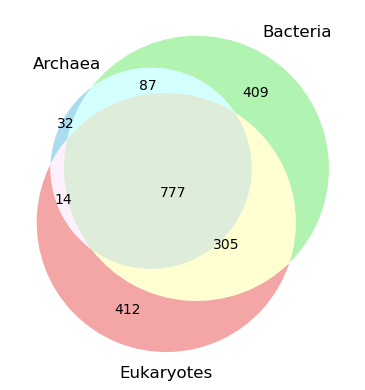

In [7]:
# Create a Venn diagram for three sets
venn3(subsets=[a, b, e], set_labels=('Archaea', 'Bacteria', 'Eukaryotes'),
      set_colors=('skyblue', 'lightgreen', 'lightcoral'), alpha=0.7)

# plt.savefig('venn_All_ECOD.svg', dpi=300, bbox_inches='tight')
plt.show()

## metabolic folds

In [8]:
# get a list of 396 metabolic folds
x_scope = x2ns.keys()

In [9]:
a_scope = set([fold for fold in a if fold in x_scope])
b_scope = set([fold for fold in b if fold in x_scope])
e_scope = set([fold for fold in e if fold in x_scope])

ab_scope = a_scope & b_scope
be_scope = b_scope & e_scope
ae_scope = a_scope & e_scope
abe_scope = a_scope & b_scope & e_scope

In [10]:
print('Metabolic Enzyme Folds')
print('----------------------')
print(f'len(archaea) = {len(a_scope)}')
print(f'len(bacteria) = {len(b_scope)}')
print(f'len(eukaryotes) = {len(e_scope)}')
print(f'len(all) = {len(a_scope | b_scope | e_scope)}')

print(f'len(ab) = {len(ab_scope)}')
print(f'len(be) = {len(be_scope)}')
print(f'len(ae) = {len(ae_scope)}')
print(f'len(abe) = {len(abe_scope)}')

Metabolic Enzyme Folds
----------------------
len(archaea) = 357
len(bacteria) = 391
len(eukaryotes) = 370
len(all) = 396
len(ab) = 356
len(be) = 366
len(ae) = 344
len(abe) = 344


In [11]:
print(a_scope - (b_scope | e_scope))  # archaea only: {'5103'}
print(b_scope - (a_scope | e_scope))  # bacteria only: {'4036', '4035', '914', '3018', '582', '6051', '3339', '4054', '640', '6113', '1055', '3847', '6174'}
print(e_scope - (b_scope | a_scope))  # eukaryotes only: {'3322', '3257', '558', '3777', '3371'}

{'5103'}
{'4054', '6174', '4035', '1055', '4036', '3847', '3339', '6051', '640', '914', '6113', '3018', '582'}
{'3371', '3777', '3322', '3257'}


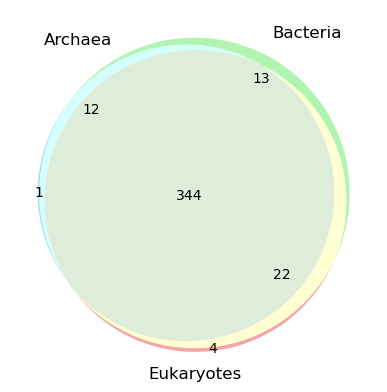

In [12]:
# Create a Venn diagram for three sets
venn3(subsets=[a_scope, b_scope, e_scope], set_labels=('Archaea', 'Bacteria', 'Eukaryotes'),
      set_colors=('skyblue', 'lightgreen', 'lightcoral'), alpha=0.7)

# plt.savefig('venn_scope.svg', dpi=300, bbox_inches='tight')
plt.show()

## unweighted venn diagrams

In [18]:
a_only = a - (b | e)
b_only = b - (a | e)
e_only = e - (b | a)
print(len(a_only), len(b_only), len(e_only))

ab_only = (a & b) - abe
ae_only = (a & e) - abe
be_only = (b & e) - abe
print(len(ab_only), len(ae_only), len(be_only))

32 409 412
87 14 305


In [19]:
a_only_s = a_scope - (b_scope | e_scope)
b_only_s = b_scope - (a_scope | e_scope)
e_only_s = e_scope - (b_scope | a_scope)
print(len(a_only_s), len(b_only_s), len(e_only_s))

ab_only_s = (a_scope & b_scope) - abe_scope
ae_only_s = (a_scope & e_scope) - abe_scope
be_only_s = (b_scope & e_scope) - abe_scope
print(len(ab_only_s), len(ae_only_s), len(be_only_s))

1 13 4
12 0 22


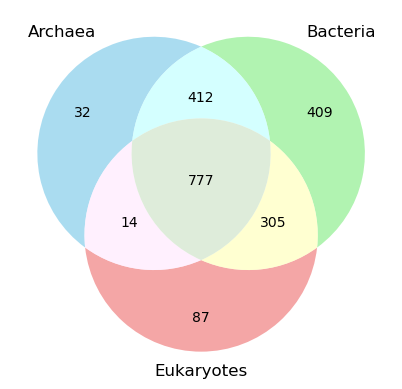

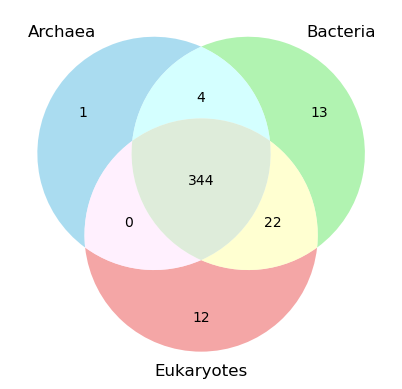

In [29]:
from matplotlib_venn import venn3_unweighted

# ECOD
subsets = [len(a_only), len(b_only), len(e_only), 
           len(ab_only), len(ae_only), len(be_only), len(abe)] 

# Create the Venn diagram
venn = venn3_unweighted(
    subsets=subsets,
    set_labels=('Archaea', 'Bacteria', 'Eukaryotes'),
    set_colors=('skyblue', 'lightgreen', 'lightcoral'),
    alpha=0.7
)

plt.savefig('venn_ECOD_unweighted.svg', dpi=300, bbox_inches='tight')
plt.show()



# scope
subsets = [len(a_only_s), len(b_only_s), len(e_only_s), 
           len(ab_only_s), len(ae_only_s), len(be_only_s), len(abe_scope)] 

# Create the Venn diagram
venn = venn3_unweighted(
    subsets=subsets,
    set_labels=('Archaea', 'Bacteria', 'Eukaryotes'),
    set_colors=('skyblue', 'lightgreen', 'lightcoral'),
    alpha=0.7
)

plt.savefig('venn_scope_unweighted.svg', dpi=300, bbox_inches='tight')
plt.show()


## stacked bar charts

In [22]:
dict_all = {'universal': len(abe), 'a_only': len(a_only), 'b_only': len(b_only), 'e_only': len(e_only), 'ab_only': len(ab_only), 'ae_only': len(ae_only), 'be_only': len(be_only)}
dict_scope = {'universal': len(abe_scope), 'a_only': len(a_only_s), 'b_only': len(b_only_s), 'e_only': len(e_only_s), 'ab_only': len(ab_only_s), 'ae_only': len(ae_only_s), 'be_only': len(be_only_s)}

# group by 3, 2, 1
dict_all = {'universal': len(abe), '1 domain': len(a_only)+ len(b_only) +len(e_only), '2 domains': len(ab_only) + len(ae_only) + len(be_only)}
dict_scope = {'universal': len(abe_scope), '1 domain': len(a_only_s)+ len(b_only_s) +len(e_only_s), '2 domains': len(ab_only_s) + len(ae_only_s) + len(be_only_s)}

In [23]:
key2color = {'universal': '#dfecda',
 'a_only': 'skyblue',
 'b_only': 'lightgreen',
 'e_only': 'lightcoral',
 'ab_only': '#d6ffff',
 'ae_only': '#fef0fe',
 'be_only': '#ffffd1'}

key2color = {'universal': '#dfecda',
 '1 domain': 'skyblue',
 '2 domains': 'lightgreen'}

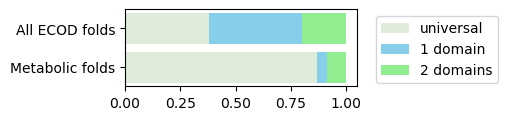

In [32]:
dict1 = dict_scope
dict2 = dict_all

dicts = [dict1, dict2]

# Keys for the bar chart
keys = list(dict1.keys())

# Normalize each dictionary
fractions = [{key: value / sum(d.values()) for key, value in d.items()} for d in dicts]

# Data for stacked bar chart
data = {key: [fractions[i][key] for i in range(len(dicts))] for key in keys}

# Plot horizontal stacked bar chart
fig, ax = plt.subplots(figsize=(3, 1))

# Positions for each bar group
y = np.arange(len(dicts))

# Plot each category as a stack with custom colors
left = np.zeros(len(dicts))
for key in keys:
    values = data[key]
    ax.barh(y, values, left=left, label=key, color=key2color[key])
    left += values  # Update left for stacking

# Add labels and legend
ax.set_yticks(y)
ax.set_yticklabels(['Metabolic folds', 'All ECOD folds'])
ax.legend(bbox_to_anchor=(1.05, 1))

# plt.savefig('fold_phyletic_affinity.svg', dpi=300, bbox_inches='tight')
plt.show()

# Compare Arc DS vs. Bac DS for each metabolic fold

In [13]:
KEGGscope = a_scope|b_scope|e_scope
xgroup2ds_a_scope = {}
xgroup2ds_b_scope = {}

for key in xgroup2ds_a.keys():
    if key in KEGGscope:
        xgroup2ds_a_scope[key] = xgroup2ds_a[key]
        
for key in xgroup2ds_b.keys():
    if key in KEGGscope:
        xgroup2ds_b_scope[key] = xgroup2ds_b[key]

ds_archaea vs. ds_bacteria: corr = 0.8149923295991075, p_value = 2.122865e-95


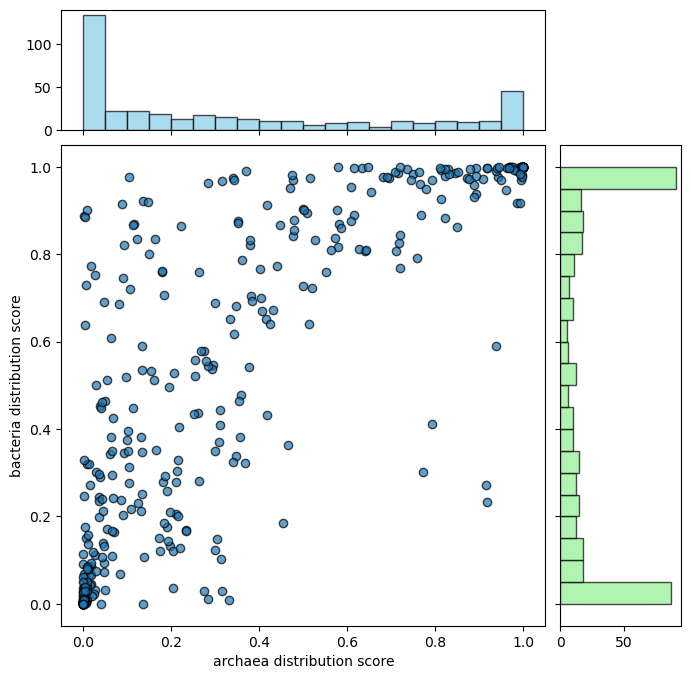

In [14]:
corr, p = pearson(xgroup2ds_a_scope, xgroup2ds_b_scope)
print(f'ds_archaea vs. ds_bacteria: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ds_a_scope, xgroup2ds_b_scope)
x = data1
y = data2

# Create a 2x2 grid layout
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)

# Scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(x, y, edgecolor='k', alpha=0.7)
ax_scatter.set_xlabel('archaea distribution score')
ax_scatter.set_ylabel('bacteria distribution score')

# Histogram on the bottom
ax_hist_bottom = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_hist_bottom.hist(x, bins=20, edgecolor='k', color='skyblue', alpha=0.7)

# Histogram on the left
ax_hist_left = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_hist_left.hist(y, bins=20, orientation='horizontal', edgecolor='k', color='lightgreen', alpha=0.7)

# Remove x-axis label from the histogram on the bottom
plt.setp(ax_hist_bottom.get_xticklabels(), visible=False)

# Remove y-axis label from the histogram on the left
plt.setp(ax_hist_left.get_yticklabels(), visible=False)

# plt.savefig('ds_ArchaeaVsBacteria.png')
plt.show()

# Comparing DS methods

Here, we compare the distribution scores obtained by 3 methods:

- (1) **50%** method: fraction of the phyla where the fold exists in >50% of the genomes within a phylum
- (2) **noPhyla** method: fraction of genomes with the given fold
- (3) **average** method: calculate the fraction of genomes with the given fold in each phylum -> take average of DS across all phyla

In [15]:
# DS_50%
a_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_50%/xgroup2DS_bacteria_recovered.csv'

# DS_average
a_ave_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_ave_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'

# DS_noPhyla
a_noPhyla_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_archaea_recovered.csv'
b_noPhyla_path = '../data/assets/xgroup2/DS_noPhyla/xgroup2DS_noPhyla_bacteria_recovered.csv'

In [16]:
# DS_50%
xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))

# average
xgroup2ds_a_ave = csv2dict(a_ave_path)
print(len(xgroup2ds_a_ave))
xgroup2ds_b_ave = csv2dict(b_ave_path)
print(len(xgroup2ds_b_ave))

# noPhyla
xgroup2ds_a_noPhyla = csv2dict(a_noPhyla_path)
print(len(xgroup2ds_a_noPhyla))
xgroup2ds_b_noPhyla = csv2dict(b_noPhyla_path)
print(len(xgroup2ds_b_noPhyla))

2230
2230
2230
2230
2230
2230


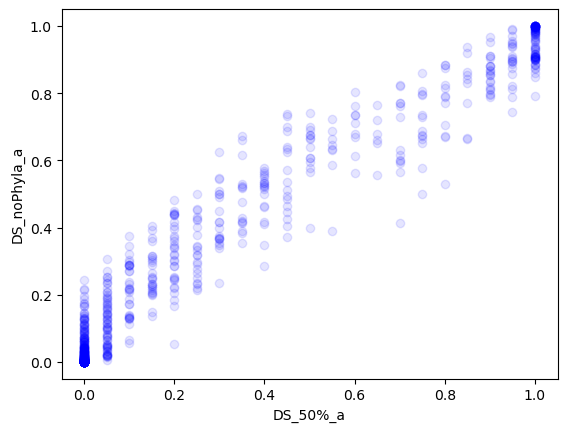

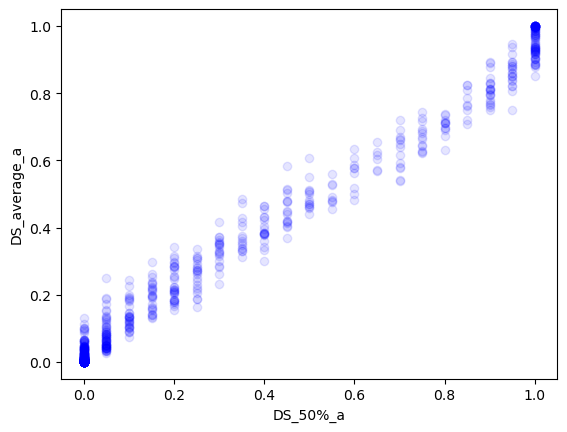

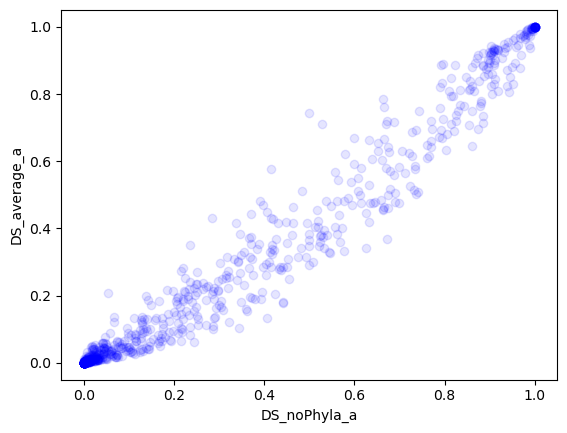

In [17]:
# archaea
scatter(xgroup2ds_a, xgroup2ds_a_noPhyla, 'DS_50%_a', 'DS_noPhyla_a')
scatter(xgroup2ds_a, xgroup2ds_a_ave, 'DS_50%_a', 'DS_average_a')
scatter(xgroup2ds_a_noPhyla, xgroup2ds_a_ave, 'DS_noPhyla_a', 'DS_average_a')

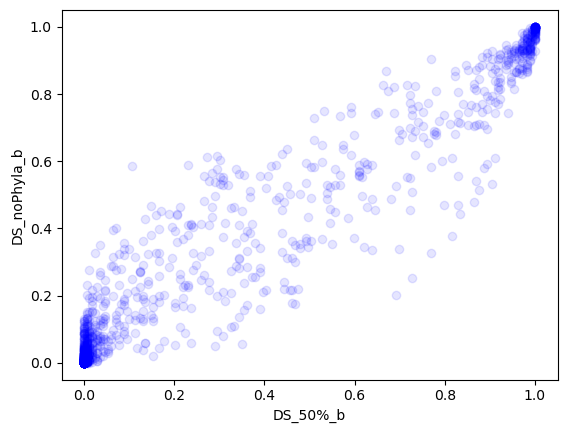

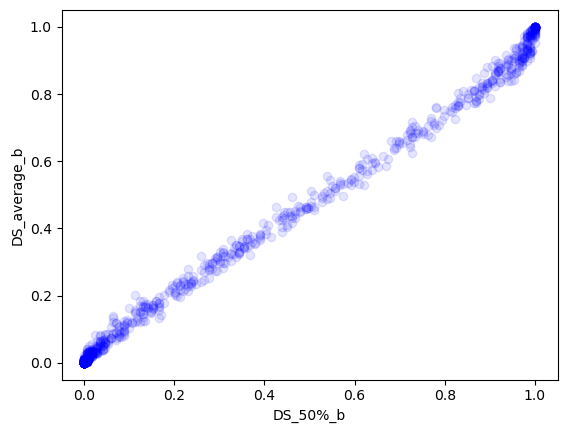

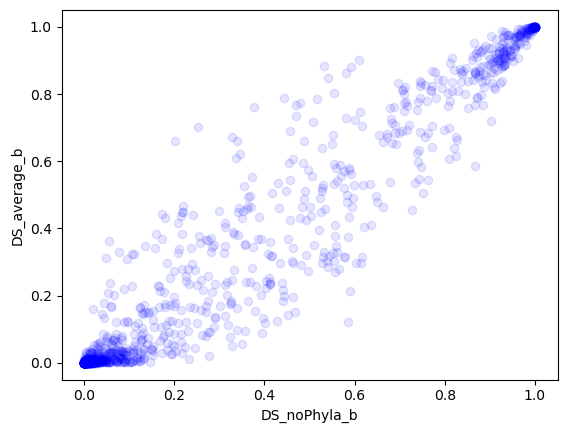

In [18]:
# bacteria
scatter(xgroup2ds_b, xgroup2ds_b_noPhyla, 'DS_50%_b', 'DS_noPhyla_b')
scatter(xgroup2ds_b, xgroup2ds_b_ave, 'DS_50%_b', 'DS_average_b')
scatter(xgroup2ds_b_noPhyla, xgroup2ds_b_ave, 'DS_noPhyla_b', 'DS_average_b')

- DS_average & DS_50% give similar scores
- noPhyla method seems to introduce biases, because it does not give equal weights to phyla with more/less genomes